In [ ]:
import io
import os
import json
import tarfile
import requests
import pandas as pd
from google.colab import files

PROJECT_ID = "TCGA-LIHC"

# --- STEP 1: FETCH THE GENE EXPRESSION DATA MATRIX ---
print("1/3: Connecting to GDC API for Gene Expression...")
files_endpt = "https://api.gdc.cancer.gov/files"
filters = {
    "op": "and",
    "content": [
        {"op": "in", "content": {"field": "cases.project.project_id", "value": [PROJECT_ID]}},
        {"op": "in", "content": {"field": "files.data_category", "value": ["Transcriptome Profiling"]}},
        {"op": "in", "content": {"field": "files.data_type", "value": ["Gene Expression Quantification"]}},
        {"op": "in", "content": {"field": "files.analysis.workflow_type", "value": ["STAR - Counts"]}}
    ]
}

# Request the mapping files
params = {
    "filters": json.dumps(filters),
    "fields": "file_id,file_name,cases.samples.submitter_id",
    "size": "600",
    "format": "JSON"
}

response = requests.get(files_endpt, params=params).json()
hits = response["data"]["hits"]

file_to_sample = {}
for hit in hits:
    try:
        sample_id = hit["cases"][0]["samples"][0]["submitter_id"]
        file_to_sample[hit["file_name"]] = sample_id
    except KeyError:
        continue

file_ids = [hit["file_id"] for hit in hits]

print("2/3: Streaming expression counts matrix directly from GDC...")
data_endpt = "https://api.gdc.cancer.gov/data"
r = requests.post(data_endpt, data=json.dumps({"ids": file_ids}), headers={"Content-Type": "application/json"})
tar_file = tarfile.open(fileobj=io.BytesIO(r.content))

expression_data = {}
# Initialize a dictionary to store the full gene ID to gene name mapping
gene_id_version_to_name_map = {}

for member in tar_file.getmembers():
    if member.name.endswith(".tsv"):
        f = tar_file.extractfile(member)
        filename = os.path.basename(member.name)
        if filename in file_to_sample:
            sample_name = file_to_sample[filename]

            df_full = pd.read_csv(f, sep="\t", comment="#", index_col=0)
            # Assuming 'unstranded' contains the desired gene expression counts.
            # This is a common column name in GDC STAR - Counts files.
            expression_data[sample_name] = df_full["unstranded"]

            # Update the global gene ID to gene name mapping
            # Only consider genes (rows starting with "ENSG") that have a gene_name
            current_file_map = df_full[df_full.index.str.startswith("ENSG")]["gene_name"].dropna().to_dict()
            gene_id_version_to_name_map.update(current_file_map)

counts_matrix = pd.DataFrame(expression_data)
counts_matrix.index.name = "Gene_ID"
counts_matrix.to_csv("TCGA_LIHC_gene_expression_counts.csv")


# --- STEP 2: FETCH THE CLINICAL METADATA ---
print("3/3: Extracting matching patient clinical parameters...")
cases_endpt = "https://api.gdc.cancer.gov/cases"
clin_filters = {"op": "in", "content": {"field": "cases.project.project_id", "value": [PROJECT_ID]}}

clin_params = {
    "filters": json.dumps(clin_filters),
    "fields": "submitter_id,demographic.gender,demographic.vital_status,demographic.days_to_death,diagnoses.age_at_diagnosis,diagnoses.ajcc_pathologic_stage",
    "size": "600",
    "format": "JSON"
}

clin_resp = requests.get(cases_endpt, params=clin_params).json()
clin_hits = clin_resp["data"]["hits"]

clinical_records = []
for hit in clin_hits:
    patient = hit.get("submitter_id", None)
    gender = hit.get("demographic", {}).get("gender", None)
    status = hit.get("demographic", {}).get("vital_status", None)
    death_days = hit.get("demographic", {}).get("days_to_death", None)

    age_days = hit.get("diagnoses", [{}])[0].get("age_at_diagnosis", None)
    age = round(age_days / 365.25, 1) if age_days else None

    stage = hit.get("diagnoses", [{}])[0].get("ajcc_pathologic_stage", None)

    clinical_records.append([patient, status, death_days, age, gender, stage])

clinical_df = pd.DataFrame(clinical_records, columns=["Patient_Barcode", "Vital_Status", "Days_to_Death", "Age", "Gender", "Tumor_Stage"])
clinical_df.to_csv("TCGA_LIHC_clinical_metadata.csv", index=False)

print("\nSuccess! Files generated in environment. Initiating download...")
files.download("TCGA_LIHC_gene_expression_counts.csv")
files.download("TCGA_LIHC_clinical_metadata.csv")

1/3: Connecting to GDC API for Gene Expression...
2/3: Streaming expression counts matrix directly from GDC...
3/3: Extracting matching patient clinical parameters...

Success! Files generated in environment. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DATA PROFILING


In [ ]:
counts = pd.read_csv(
    "TCGA_LIHC_gene_expression_counts.csv",
    index_col=0
)

counts.shape
counts.head()

,TCGA-DD-AAW1-01A,TCGA-ED-A66Y-01A,TCGA-DD-AAVX-01A,TCGA-DD-A115-01A,TCGA-DD-AACN-01A,TCGA-DD-A4NJ-01A,TCGA-DD-AACS-01A,TCGA-DD-A118-11A,TCGA-DD-A118-01A,TCGA-DD-A1EG-11A,...,TCGA-CC-A5UE-01A,TCGA-5R-AA1D-01A,TCGA-DD-A4NG-01A,TCGA-2Y-A9HB-01A,TCGA-FV-A3R2-11A,TCGA-WQ-AB4B-01A,TCGA-ED-A7PZ-01A,TCGA-CC-A9FS-01A,TCGA-CC-A5UC-01A,TCGA-FV-A2QQ-01A
Gene_ID,,,,,,,,,,,,,,,,,,,,,
N_unmapped,1409695,1123687,3802960,620612,2012195,862474,571615,480977,1765755,11334563,...,2794822,1657263,1681634,1801511,2199231,790040,2613864,2990903,823424,1269206
N_multimapping,5476674,4892853,3927848,3883296,4317766,2942286,2202027,3535373,6702531,7932313,...,4628912,5761745,9025028,4578856,5043962,4475521,6983966,6283106,3556357,5146946
N_noFeature,1868900,2137163,638897,921402,1766378,2279278,1122016,644756,1504323,1071569,...,1300410,1014740,1597601,1477662,1046627,710572,1411422,1851987,728902,1126905
N_ambiguous,6049905,7157490,3725389,4739359,6515230,3613353,3590402,3713749,9145105,5489589,...,6022249,4715131,5535043,6511655,5601533,4350240,7978325,6011036,4384099,6681952
ENSG00000000003.15,16122,2349,3815,2332,3015,3382,4530,3008,5995,3729,...,13833,3844,7045,2372,3034,3189,6414,32888,5147,4885


In [ ]:
counts.isnull().sum().sum()

np.int64(0)

In [ ]:
sample_types = []

for sample in counts.columns:
    code = sample.split("-")[3][:2]

    if code == "01":
        sample_types.append("Tumor")

    elif code == "11":
        sample_types.append("Normal")

    else:
        sample_types.append("Other")

metadata = pd.DataFrame({
    "sample": counts.columns,
    "group": sample_types
})

metadata["group"].value_counts()

,count
group,
Tumor,371
Normal,50
Other,3


In [ ]:
keep = metadata["group"].isin(["Tumor","Normal"])

metadata = metadata[keep]

counts = counts[metadata["sample"]]

In [ ]:
import numpy as np

# Filter out non-gene rows from counts before log transformation
# Assuming gene IDs start with 'ENSG'
gene_rows_mask = counts.index.str.startswith("ENSG")
counts_filtered = counts[gene_rows_mask]

counts_log = np.log2(counts_filtered + 1)

PCA

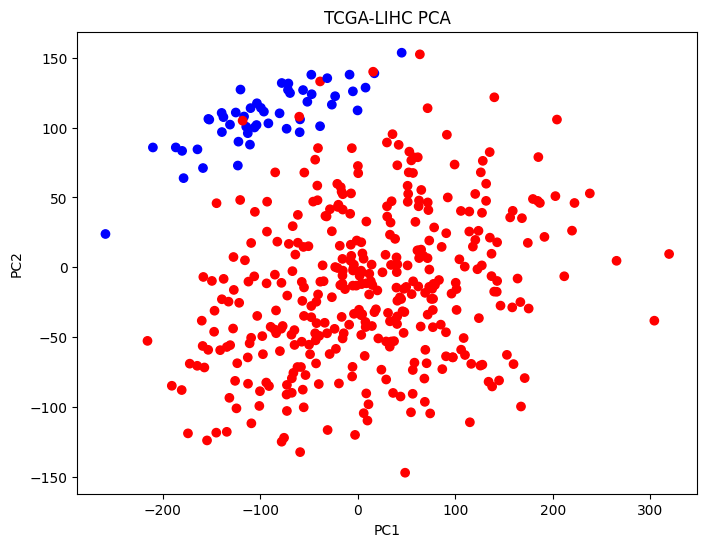

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X = pca.fit_transform(counts_log.T)

plt.figure(figsize=(8,6))

colors = metadata["group"].map({
    "Tumor":"red",
    "Normal":"blue"
})

plt.scatter(
    X[:,0],
    X[:,1],
    c=colors
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("TCGA-LIHC PCA")

plt.show()

DIFFERENTIAL EXPRESSION


In [ ]:
import statsmodels.api as sm
design = pd.get_dummies(
    metadata["group"],
    drop_first=True
).astype(float)

design = sm.add_constant(design)

In [ ]:
import numpy as np
import statsmodels.api as sm

results = []

# Filter out genes with zero variance from counts_log
# This prevents OLS models from failing due to constant gene expression across samples
# The .var(axis=1) calculates variance for each gene (row)
genes_to_analyze = counts_log.index[counts_log.var(axis=1) > 0]

for gene in genes_to_analyze:
    y = counts_log.loc[gene].values

    model = sm.OLS(y, design).fit()

    if "Tumor" in model.params and "Tumor" in model.pvalues:
        # Map Ensembl ID to gene symbol, fall back to Ensembl ID if not found
        gene_symbol = gene_id_version_to_name_map.get(gene, gene)
        results.append([
            gene_symbol,
            model.params["Tumor"],
            model.pvalues["Tumor"]
        ])

CREATE DATAFRAME

In [ ]:
res = pd.DataFrame(
    results,
    columns=[
        "Gene",
        "log2FC",
        "pvalue"
    ]
)

In [ ]:
import numpy as np
from statsmodels.stats.multitest import multipletests

# Initialize padj with NaNs
res["padj"] = np.nan

# Filter for rows where pvalue is not NaN
valid_p_mask = res["pvalue"].notna()
valid_pvalues = res.loc[valid_p_mask, "pvalue"]

if not valid_pvalues.empty:
    # Perform multiple testing correction on valid p-values
    _, p_adj_corrected, _, _ = multipletests(valid_pvalues, method="fdr_bh")
    # Assign corrected p-values back to the 'padj' column at the correct positions
    res.loc[valid_p_mask, "padj"] = p_adj_corrected

SIGNIFICANT GENES

In [ ]:
sig = res[
    (res["padj"] < 0.05)
]

In [ ]:
sig.shape

(23584, 4)

VOLCANO PLOT

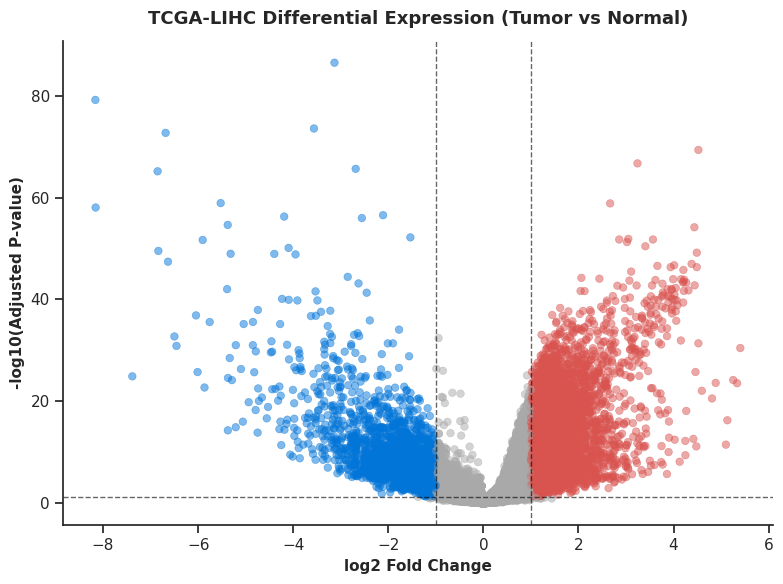

In [ ]:
plt.figure(figsize=(8, 6))
import seaborn as sns
sns.set_theme(style="ticks")

# Define colors based on significance for genes
res["plot_color"] = "grey" # Default color for non-significant genes

# Red for significant and up-regulated genes (log2FC > 1 and padj < 0.05)
res.loc[(res["padj"] < 0.05) & (res["log2FC"] > 1), "plot_color"] = "re"

# Blue for significant and down-regulated genes (log2FC < -1 and padj < 0.05)
res.loc[(res["padj"] < 0.05) & (res["log2FC"] < -1), "plot_color"] = "b"

colors = {"grey": "darkgray", "re": "#D9534F", "b": "#0275D8"}

sns.scatterplot(
    data=res,
    x="log2FC",
    y=-np.log10(res["padj"]),
    hue="plot_color",
    palette=colors,
    alpha=0.5,
    s=30,
    edgecolor=None
)

# Standardized threshold layout
plt.axvline(1, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.axvline(-1, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, alpha=0.6)

plt.title("TCGA-LIHC Differential Expression (Tumor vs Normal)", fontsize=13, weight="bold", pad=12)
plt.xlabel("log2 Fold Change", fontsize=11, weight="bold")
plt.ylabel("-log10(Adjusted P-value)", fontsize=11, weight="bold")
plt.legend().remove() # Removes the raw color string variable names from displaying
sns.despine()
plt.tight_layout()

plt.savefig("volcano_tcga_lihc.png", dpi=300, bbox_inches="tight")
plt.show()

HEATMAP


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


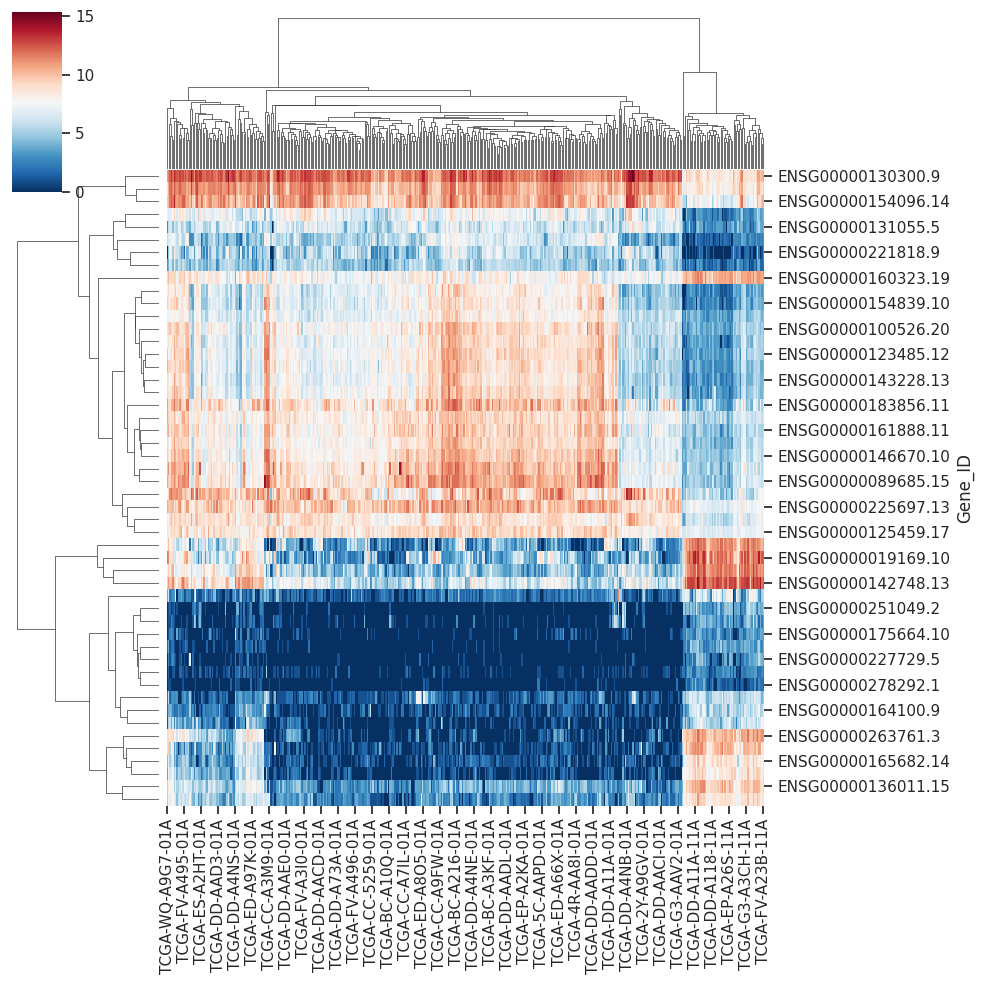

In [ ]:

import seaborn as sns

top50_gene_symbols = sig.sort_values(
    "padj"
).head(50)["Gene"]

# Create a reverse mapping from gene symbol to Ensembl ID from the available map
# Note: If multiple Ensembl IDs map to the same symbol, this will arbitrarily pick one.
# For visualization purposes, this is generally acceptable.
gene_symbol_to_ensembl_id_map = {v: k for k, v in gene_id_version_to_name_map.items()}

# Map the top50 gene symbols back to Ensembl IDs
top50_ensembl_ids = [gene_symbol_to_ensembl_id_map.get(symbol, None) for symbol in top50_gene_symbols]

# Filter out any symbols that could not be mapped to an Ensembl ID
top50_ensembl_ids = [gene_id for gene_id in top50_ensembl_ids if gene_id is not None]

# Further filter to ensure only Ensembl IDs present in counts_log index are used
final_ensembl_ids = [gene_id for gene_id in top50_ensembl_ids if gene_id in counts_log.index]

if not final_ensembl_ids:
    print("Warning: No matching Ensembl IDs found in counts_log for the top 50 gene symbols. Heatmap cannot be generated.")
else:
    heatmap_data = counts_log.loc[final_ensembl_ids]

    sns.clustermap(
        heatmap_data,
        cmap="RdBu_r",
        figsize=(10,10)
    )

In [ ]:
plt.savefig(
    "heatmap_top50.png",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

GSEA

In [ ]:
import gseapy as gp
# Isolate your columns and drop missing values
ranking = res[["Gene", "log2FC"]].dropna()

# Fix: Remove duplicate gene symbol entries to clear out the 18.47% collision warning
ranking = ranking.sort_values("log2FC", ascending=False)
ranking = ranking.drop_duplicates(subset=["Gene"], keep="first")

# Execute GSEA securely using your clean unique vector
gp.prerank(
    rnk=ranking,
    gene_sets=["MSigDB_Hallmark_2020", "KEGG_2021_Human", "Reactome_2022"],
    outdir="gsea_results"
)

2026-06-17 13:09:12,239 [WARNING] Duplicated values found in preranked stats: 17.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


SURVIVAL ANALYSIS


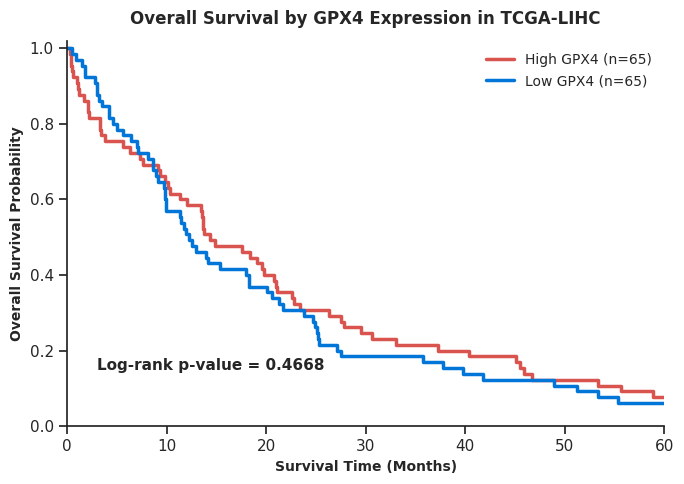

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load files
exp_matrix = pd.read_csv("TCGA_LIHC_gene_expression_counts.csv", index_col=0)
clinical_df = pd.read_csv("TCGA_LIHC_clinical_metadata.csv")

# Filter for primary tumor samples only (Sample code 01)
tumor_columns = [col for col in exp_matrix.columns if col.split("-")[3].startswith("01")]
filtered_exp = exp_matrix[tumor_columns]

# Get the Ensembl ID for GPX4 using the pre-existing map
gpx4_ensembl_id = gene_symbol_to_ensembl_id_map.get("GPX4")

if gpx4_ensembl_id is None:
    raise ValueError("GPX4 Ensembl ID not found in gene mapping. Please ensure GPX4 was part of the original gene expression data.")

# Ensure the found Ensembl ID actually exists in the filtered expression matrix
if gpx4_ensembl_id in filtered_exp.index:
    gpx4_expr = filtered_exp.loc[gpx4_ensembl_id]
else:
    raise ValueError(f"Ensembl ID '{gpx4_ensembl_id}' for GPX4 not found in filtered expression matrix index.")

gpx4_df = pd.DataFrame({"GPX4_Expression": gpx4_expr})
gpx4_df["Patient_Barcode"] = gpx4_df.index.str[:12]

# Inner join on barcode
merged_df = pd.merge(clinical_df, gpx4_df, on="Patient_Barcode", how="inner")

# Track time and event attributes
if "Days_to_Last_FollowUp" in merged_df.columns:
    merged_df["Survival_Time"] = np.where(
        merged_df["Vital_Status"] == "Dead",
        merged_df["Days_to_Death"],
        merged_df["Days_to_Last_FollowUp"]
    )
else:
    # If 'Days_to_Last_FollowUp' is not present, set survival time to NaN for 'Alive' patients.
    # These will be dropped by the subsequent merged_df.dropna(...) line.
    merged_df["Survival_Time"] = np.where(
        merged_df["Vital_Status"] == "Dead",
        merged_df["Days_to_Death"],
        np.nan # No last follow up info for alive patients
    )

merged_df["Survival_Time"] = pd.to_numeric(merged_df["Survival_Time"], errors="coerce")
merged_df["Event"] = np.where(merged_df["Vital_Status"] == "Dead", 1, 0)
merged_df = merged_df.dropna(subset=["Survival_Time", "GPX4_Expression"])

# Normalize timeline to months
merged_df["Survival_Months"] = merged_df["Survival_Time"] / 30.4375

# Stratify by median cutoff
median_cutoff = merged_df["GPX4_Expression"].median()
merged_df["Expression_Group"] = np.where(
    merged_df["GPX4_Expression"] > median_cutoff, "High GPX4", "Low GPX4"
)

high_group = merged_df[merged_df["Expression_Group"] == "High GPX4"]
low_group = merged_df[merged_df["Expression_Group"] == "Low GPX4"]

# Log-rank test
lr_results = logrank_test(
    high_group["Survival_Months"], low_group["Survival_Months"],
    event_observed_A=high_group["Event"], event_observed_B=low_group["Event"]
)

# Plot KM Survival Function
plt.figure(figsize=(7, 5))
sns.set_theme(style="ticks")

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(high_group["Survival_Months"], event_observed=high_group["Event"], label=f"High GPX4 (n={len(high_group)})")
ax = kmf_high.plot_survival_function(color="#D9534F", linewidth=2.5, ci_show=False)

kmf_low.fit(low_group["Survival_Months"], event_observed=low_group["Event"], label=f"Low GPX4 (n={len(low_group)})")
kmf_low.plot_survival_function(ax=ax, color="#0275D8", linewidth=2.5, ci_show=False)

# Annotate stat metrics
plt.text(
    x=3, y=0.15,
    s=f"Log-rank p-value = {lr_results.p_value:.4f}",
    fontsize=11, weight="bold", bbox=dict(facecolor='white', alpha=0.9, edgecolor='none')
)

plt.title("Overall Survival by GPX4 Expression in TCGA-LIHC", fontsize=12, weight="bold", pad=12)
plt.xlabel("Survival Time (Months)", fontsize=10, weight="bold")
plt.ylabel("Overall Survival Probability", fontsize=10, weight="bold")
plt.xlim(0, 60)
plt.ylim(0, 1.02)
plt.legend(frameon=False, loc="upper right", fontsize=10)

sns.despine()
plt.tight_layout()

# Export figure asset
plt.savefig("km_curve_gpx4_lihc.png", dpi=300)
plt.show()

In [ ]:
print(merged_df.shape)

print(
    merged_df["Expression_Group"]
    .value_counts()
)

print(
    lr_results.p_value
)

(130, 11)
Expression_Group
High GPX4    65
Low GPX4     65
Name: count, dtype: int64
0.4667731113719349


Hazard Ratio

In [ ]:
!pip install lifelines

In [ ]:
from lifelines import CoxPHFitter

cox_df = merged_df[
    ["Survival_Months",
     "Event",
     "GPX4_Expression"]
].copy()

cph = CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="Survival_Months",
    event_col="Event"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 130 total observations, 0 right-censored observations>
             duration col = 'Survival_Months'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 130
number of events observed = 130
   partial log-likelihood = -505.81
         time fit was run = 2026-06-17 13:53:54 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
GPX4_Expression -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                 cmp to     z    p  -log2(p)
covariate                                   
GPX4_Expression    0.00 -0.79 0.43      1.21
---
Concordance = 0.49
Partial AIC = 1013.62
log-likelihood ratio test = 0.64 on 1 df
-log2(p) of ll-ratio test = 1.24

Boxplot of GPX4 Expression

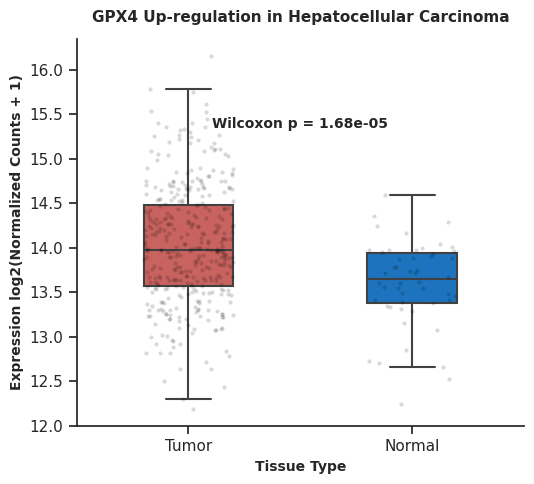

In [ ]:
# Format data frame
tumor_values = counts_log.loc[gpx4_ensembl_id, tumor_samples].tolist()
normal_values = counts_log.loc[gpx4_ensembl_id, normal_samples].tolist()

plot_df = pd.DataFrame({
    "Expression": tumor_values + normal_values,
    "Group": ["Tumor"] * len(tumor_samples) + ["Normal"] * len(normal_samples)
})

# Calculate statistical significance
stat, p_val = ranksums(tumor_values, normal_values)

# Plotting configuration
plt.figure(figsize=(5.5, 5))
sns.set_theme(style="ticks")

# Custom signature palette: Normal Blue and Tumor Red
cohort_colors = {"Tumor": "#D9534F", "Normal": "#0275D8"}

# Draw underlying box structures
sns.boxplot(
    data=plot_df,
    x="Group",
    y="Expression",
    hue="Group",
    palette=cohort_colors,
    width=0.4,
    fliersize=0,
    linewidth=1.5,
    legend=False
)

# Layer jittered raw data points for transparency
sns.stripplot(
    data=plot_df,
    x="Group",
    y="Expression",
    color="black",
    alpha=0.15,
    size=3,
    jitter=0.2,
    dodge=False
)

# Dynamic text annotation for statistical weight
plt.text(
    x=0.5, y=plot_df["Expression"].max() * 0.95,
    s=f"Wilcoxon p = {p_val:.2e}",
    fontsize=10, weight="bold", ha="center"
)

# Figure labels and aesthetics
plt.title("GPX4 Up-regulation in Hepatocellular Carcinoma", fontsize=11, weight="bold", pad=12)
plt.xlabel("Tissue Type", fontsize=10, weight="bold")
plt.ylabel("Expression log2(Normalized Counts + 1)", fontsize=10, weight="bold")

sns.despine()
plt.tight_layout()

# Export figure asset
plt.savefig("gpx4_tumor_normal_boxplot.png", dpi=300)
plt.show()

Correlation With Ferroptosis Genes

In [ ]:
ferro_genes = [
    "GPX4",
    "SLC7A11",
    "ACSL4",
    "FTH1",
    "TFRC"
]

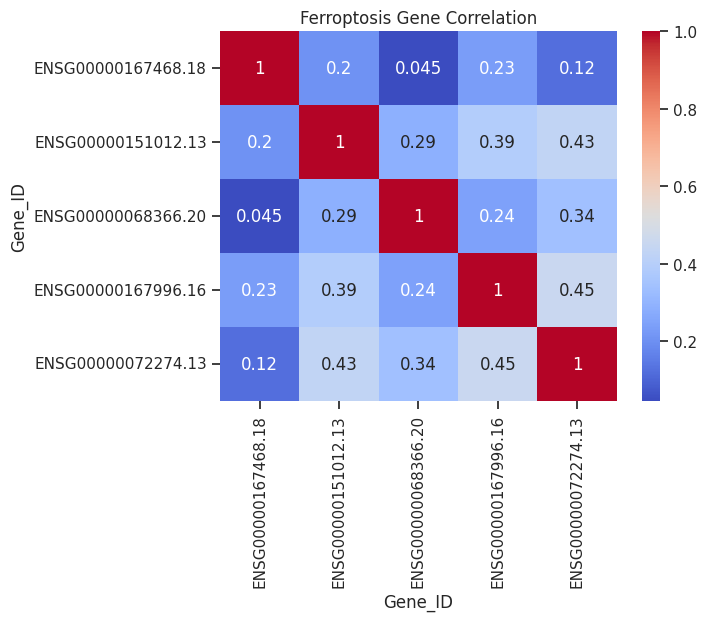

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter counts_log for ferroptosis-related genes
# Ensure only genes present in counts_log are selected
ferro_genes_in_data = [gene_id for gene_id in ferro_genes if gene_id in gene_symbol_to_ensembl_id_map]

# Map gene symbols to Ensembl IDs and filter counts_log
gene_expr_df = counts_log.loc[
    [gene_symbol_to_ensembl_id_map[gene_symbol] for gene_symbol in ferro_genes_in_data]
]

corr_matrix = gene_expr_df.T.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Ferroptosis Gene Correlation"
)

plt.savefig(
    "ferroptosis_correlation_heatmap.png",
    dpi=300
)

plt.show()